In [1]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

# Latent dimension
latent_dim = 2

# -----------------------------
# Encoder
# -----------------------------
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Reparameterization Trick
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# -----------------------------
# Decoder
# -----------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# -----------------------------
# VAE Model
# -----------------------------
outputs = decoder(encoder(encoder_inputs)[2])
vae = Model(encoder_inputs, outputs, name="vae")

# -----------------------------
# Loss Function
# -----------------------------
reconstruction_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(encoder_inputs, outputs)
) * 28 * 28

kl_loss = -0.5 * tf.reduce_mean(
    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
)

vae_loss = reconstruction_loss + kl_loss
vae.add_loss(vae_loss)

# Compile
vae.compile(optimizer="adam")

# -----------------------------
# Train Model
# -----------------------------
history = vae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# -----------------------------
# Generate New Digits
# -----------------------------
n = 10
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-2, 2, n)
grid_y = np.linspace(-2, 2, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[
            i * digit_size: (i + 1) * digit_size,
            j * digit_size: (j + 1) * digit_size
        ] = digit

# Display generated images
plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.show()

C:\Users\adhit\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.0.1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [2]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 3.20.3

    Uninstalling protobuf-3.20.3:

   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   --

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.9 requires protobuf<4,>=3.11, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.46.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.13.2 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.3 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.34.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.

[notice] A new release of pip is available: 26.0 ->

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 206.6913 - val_loss: 174.2246
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 170.2438 - val_loss: 167.5277
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 166.2849 - val_loss: 165.2593
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 164.2703 - val_loss: 163.5548
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 162.6151 - val_loss: 162.1611
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 161.1831 - val_loss: 161.1485
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 159.9393 - val_loss: 159.6424
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 158.8098 - val_loss: 158.5096
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 157.8140 - val_loss: 157.6015
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 156.9140 - val_loss: 156.7611
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 156.1152 - val_loss: 156.1711
Epoch 12

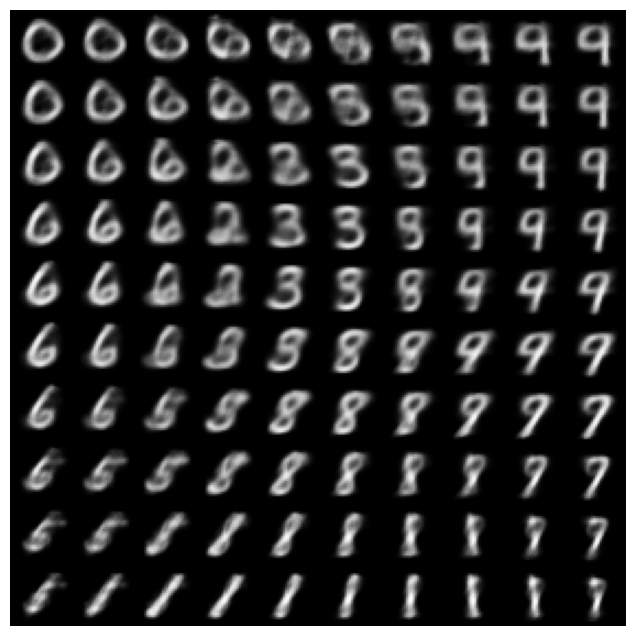

In [3]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load & Preprocess Data
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

latent_dim = 2

# -----------------------------
# Encoder
# -----------------------------
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# -----------------------------
# Decoder
# -----------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# -----------------------------
# Custom VAE Model
# -----------------------------
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstruction)
        ) * 28 * 28

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        # Total loss
        self.add_loss(reconstruction_loss + kl_loss)

        return reconstruction

# Create model
vae = VAE(encoder, decoder)

# Compile
vae.compile(optimizer="adam")

# -----------------------------
# Train Model
# -----------------------------
history = vae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# -----------------------------
# Generate New Digits
# -----------------------------
n = 10
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-2, 2, n)
grid_y = np.linspace(-2, 2, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)

        figure[
            i * digit_size:(i + 1) * digit_size,
            j * digit_size:(j + 1) * digit_size
        ] = digit

# Show generated digits
plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.show()